# Notebook 6.1: Statistical Foundations for Signal Processing

## Financial Trading with Python, 2nd Edition

---

Before we can filter noise from financial data, we need to understand what our data
actually looks like. This notebook builds the statistical intuition required before
applying any signal processing technique.

Most signal processing methods were developed in engineering and physics, where the
underlying signal has known properties (a radio wave, a vibration frequency, a sensor
reading). Financial data is fundamentally different. Returns are noisy, non-normal,
and often lack the kind of structure that filters are designed to extract.
Understanding these properties first will help us set realistic expectations and
choose appropriate techniques in the notebooks that follow.

This notebook covers:

- Probability distributions and the four principal moments
- Stationarity and why filters assume it
- Trends and seasonality
- Autocorrelation and partial autocorrelation

By the end of this notebook, you will know which of our case study series have
structure worth filtering, and which do not.

## Section 1: Loading Data and Setting Context

### 1.1 Where We Are in the Workflow

In Chapter 3, we retrieved daily price data for our four case study instruments and
saved it as a parquet file. In Chapter 5, we prepared that data: aligning dates,
handling missing values, and validating the result.

Now we are at a decision point. We have clean data and we need to decide whether
signal processing techniques can improve the quality of the trading signals we will
generate in later chapters. Before we try any filtering, we need to understand the
statistical properties of what we are working with. That is the purpose of this
notebook.

### 1.2 Imports and Configuration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set_theme()

# Display settings
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

### 1.2 Loading the Case Study Data

We load the aligned daily price data from Chapter 3. As a reminder, our four instruments are:

- **SPY**: S&P 500 ETF (our risky asset)
- **BIL**: Short-term Treasury ETF (our safe asset)
- **VIXY**: VIX short-term futures ETF (our tail hedge instrument)
- **VIX**: CBOE Volatility Index (our signal source, not traded directly)

In [6]:
df_prices = pd.read_parquet('case_study_prices.parquet')

print(f"Shape: {df_prices.shape}")
print(f"Date range: {df_prices.index[0].strftime('%Y-%m-%d')} to {df_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Columns: {list(df_prices.columns)}")
print(f"\nMissing values:\n{df_prices.isna().sum()}")
df_prices.head()


Shape: (3771, 4)
Date range: 2011-01-04 to 2025-12-31
Columns: ['BIL', 'SPY', 'VIXY', '^VIX']

Missing values:
BIL     0
SPY     0
VIXY    0
^VIX    0
dtype: int64


,BIL,SPY,VIXY,^VIX
Date,,,,
2011-01-04,74.9744,97.1394,633840.0000,17.3800
2011-01-05,74.9744,97.6442,620400.0000,17.0200
2011-01-06,74.9744,97.4530,623040.0000,17.4000
2011-01-07,74.9580,97.2618,624320.0000,17.1400
2011-01-10,74.9744,97.1394,623040.0000,17.5400


### 1.3 Calculating Returns

Throughout this notebook, we will work with both prices and returns. Most statistical tests and signal processing techniques operate on returns rather than raw prices. We calculate simple daily returns here for use in the sections that follow.

Note that VIX is an index, not a traded asset. We calculate its daily changes for analysis purposes, but these are not tradeable returns.

In [7]:
df_returns = df_prices.pct_change().dropna()

print(f"Returns shape: {df_returns.shape}")
print(f"Date range: {df_returns.index[0].strftime('%Y-%m-%d')} to {df_returns.index[-1].strftime('%Y-%m-%d')}")
print(f"\nBasic statistics:")
df_returns.describe().round(4)

Returns shape: (3770, 4)
Date range: 2011-01-05 to 2025-12-31

Basic statistics:


,BIL,SPY,VIXY,^VIX
count,3770.0000,3770.0000,3770.0000,3770.0000
mean,0.0001,0.0006,-0.0017,0.0031
std,0.0002,0.0108,0.0441,0.0835
min,-0.0004,-0.1094,-0.2092,-0.3575
25%,0.0000,-0.0037,-0.0253,-0.0426
50%,0.0000,0.0007,-0.0063,-0.0066
75%,0.0002,0.0058,0.0152,0.0362
max,0.0008,0.1050,0.4305,1.1560


The data is clean and aligned with no missing values across 3,771 trading days from January 2011 through December 2025. This is the result of the preparation work we did in Chapter 5.

A few things to note from the summary statistics, even before we dig deeper:

- SPY has a small positive mean daily return (0.06%), as we would expect from an equity index over a long period.
- VIXY has a negative mean return (-0.17%). This is by design: VIX futures ETFs suffer from persistent roll cost (contango decay), which is why VIXY is only useful as a short-term hedge, not a buy-and-hold position.
- The min and max values hint at extreme events we will examine more closely when we look at distributions in Section 2.
- BIL has very small returns with near-zero volatility, consistent with its role as a near-cash instrument.

With our data loaded and returns calculated, we are ready to examine the statistical properties that will determine which signal processing techniques, if any, are appropriate for our case study.

## Section 2: Probability Distributions and the Four Moments

Every signal processing technique makes assumptions about the data it operates on. Most were designed for signals that follow, or approximately follow, a normal (Gaussian) distribution. Financial returns are famously non-normal: they have fatter tails, are often asymmetric, and exhibit clustering of extreme values.

Understanding the shape of our return distributions through the four principal moments (mean, variance, skewness, and kurtosis) is not just an academic exercise. It tells us whether the assumptions behind our filters hold, and where they break down.

If you apply a filter that assumes normally distributed noise to data with fat tails, the filter will underestimate the probability of extreme events. For a volatility tail hedge strategy like ours, that is exactly wrong: the extreme events are what we are trying to capture.

### 2.1 Visualizing Return Distributions

We start by plotting histograms of daily returns for each of our four instruments, overlaid with a fitted normal distribution. The visual gap between the histogram and the normal curve tells us immediately how far from Gaussian our data really is.

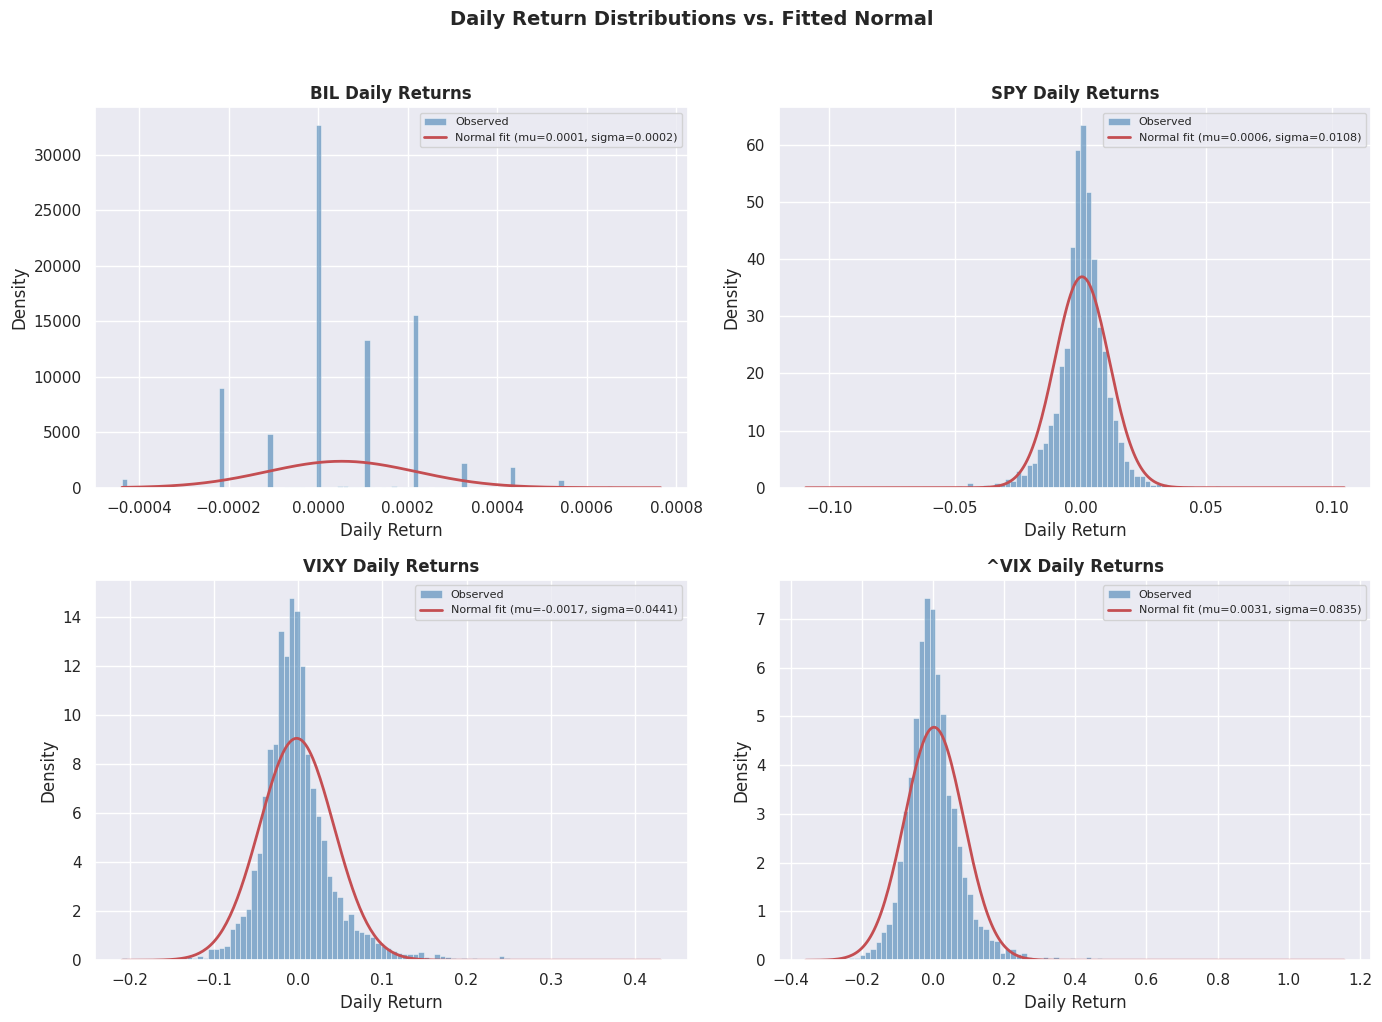

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), df_returns.columns):
    data = df_returns[col].dropna()

    # Plot histogram
    ax.hist(data, bins=100, density=True, alpha=0.6, color='steelblue',
            edgecolor='white', linewidth=0.5, label='Observed')

    # Overlay fitted normal distribution
    x = np.linspace(data.min(), data.max(), 300)
    mu, sigma = data.mean(), data.std()
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
            label=f'Normal fit (mu={mu:.4f}, sigma={sigma:.4f})')

    ax.set_title(f'{col} Daily Returns', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')

plt.suptitle('Daily Return Distributions vs. Fitted Normal',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The pattern is clear across all four instruments. The observed histograms are taller and narrower in the center than the normal curve (this is called leptokurtosis), and they have more mass in the tails. This means there are both more "boring" days (small returns clustered near zero) and more extreme days (large moves) than a normal distribution would predict.

BIL is so concentrated around zero that the normal fit is essentially flat by comparison. SPY shows the classic equity pattern: a tight peak with tails extending further than the red curve. VIXY and VIX are the most striking. Both have long right tails reflecting the sharp spikes that occur during market stress. VIXY returns reaching 0.43 (43% in a single day) and VIX changes exceeding 1.15 (115%) are far outside anything a normal distribution would predict. These spikes are the entire reason VIXY exists as a hedge instrument.

### 2.2 The Four Principal Moments

The four moments give us a precise numerical description of each distribution:

1. **Mean**: The average return. For daily data, this is typically very small and close to zero.
2. **Standard deviation** (square root of variance): The dispersion of returns around the mean. This is the foundation of volatility measurement.
3. **Skewness**: Measures asymmetry. Negative skew means the left tail is longer (larger losses than gains), which is typical for equities. Positive skew means the right tail is longer.
4. **Kurtosis**: Measures tail thickness. A normal distribution has a kurtosis of 3.0 (or excess kurtosis of 0). Values above 3 indicate fatter tails (more extreme events). Financial returns almost always have excess kurtosis.

We calculate all four for each of our instruments.

In [9]:
def calculate_moments(series, name):
    """Calculate the four principal moments for a return series."""
    return {
        'Instrument': name,
        'Mean': series.mean(),
        'Std Dev': series.std(),
        'Skewness': series.skew(),
        'Kurtosis': series.kurtosis(),  # pandas reports excess kurtosis
        'Observations': len(series)
    }

moments = [calculate_moments(df_returns[col], col) for col in df_returns.columns]
df_moments = pd.DataFrame(moments).set_index('Instrument')

print("Four Principal Moments of Daily Returns")
print("=" * 65)
print(f"\nNote: Kurtosis shown is excess kurtosis (normal distribution = 0)")
print(f"      Negative skew = larger losses than gains")
print(f"      Positive excess kurtosis = fatter tails than normal\n")
df_moments.round(4)

Four Principal Moments of Daily Returns

Note: Kurtosis shown is excess kurtosis (normal distribution = 0)
      Negative skew = larger losses than gains
      Positive excess kurtosis = fatter tails than normal



,Mean,Std Dev,Skewness,Kurtosis,Observations
Instrument,,,,,
BIL,0.0001,0.0002,0.2366,0.8953,3770
SPY,0.0006,0.0108,-0.3484,12.8933,3770
VIXY,-0.0017,0.0441,1.6848,9.5760,3770
^VIX,0.0031,0.0835,2.2730,17.3303,3770


The numbers confirm what the histograms showed visually:

- **BIL** has near-zero skewness (0.24) and low excess kurtosis (0.90). This is the closest to a normal distribution in our dataset, consistent with its role as a near-cash instrument. BIL is not interesting from a signal processing perspective.
- **SPY** has negative skewness (-0.35), meaning losses are larger than gains, and significant excess kurtosis (12.89). A normal distribution has excess kurtosis of zero. A value of 12.89 means SPY experiences extreme daily moves far more often than a Gaussian model would predict.
- **VIXY** has positive skewness (1.68) and high excess kurtosis (9.58). The positive skew reflects the explosive upward moves during market stress. The fat tails on both sides mean VIXY is volatile in both directions.
- **VIX** is the most extreme: skewness of 2.27 and excess kurtosis of 17.33. VIX is a mean-reverting series that occasionally explodes upward, and the distribution captures both of those properties.

The key takeaway for signal processing: every instrument except BIL has distributions that deviate substantially from normality. Any filter that assumes Gaussian noise will underestimate the probability and magnitude of extreme events.

### 2.3 Testing for Normality

The Jarque-Bera test provides a formal statistical test for normality. It tests whether the skewness and kurtosis of a sample are consistent with a normal distribution. A low p-value (below 0.05) means we reject the null hypothesis that the data is normally distributed.

Based on what we have already seen, we expect to reject normality for all four instruments. This test puts a number on our visual intuition.

In [10]:
print("Jarque-Bera Test for Normality")
print("=" * 55)
print(f"{'Instrument':<12} {'JB Statistic':>14} {'p-value':>14} {'Normal?':>10}")
print("-" * 55)

for col in df_returns.columns:
    jb_stat, jb_pvalue = stats.jarque_bera(df_returns[col].dropna())
    is_normal = 'Yes' if jb_pvalue > 0.05 else 'No'
    print(f"{col:<12} {jb_stat:>14.2f} {jb_pvalue:>14.6f} {is_normal:>10}")

Jarque-Bera Test for Normality
Instrument     JB Statistic        p-value    Normal?
-------------------------------------------------------
BIL                  160.26       0.000000         No
SPY                26113.52       0.000000         No
VIXY               16143.67       0.000000         No
^VIX               50288.34       0.000000         No


All four instruments reject normality with p-values that are effectively zero. Even BIL, which looked closest to normal in the histograms, has a Jarque-Bera statistic of 160 driven by its slight skewness and kurtosis.

The magnitude of the test statistics tells its own story. VIX at 50,288 and SPY at 26,114 are not marginal rejections. These distributions are fundamentally non-Gaussian. This is not surprising to experienced practitioners, but it is important to quantify because it directly affects how we should think about the signal processing techniques in the notebooks that follow.

When we apply a Kalman filter in Notebook 6.3, it assumes Gaussian process and measurement noise. When we use Fourier transforms, the filtering threshold is often set based on a noise floor assumed to be Gaussian. In both cases, the non-normality of our data means the "optimal" filter settings from textbook formulas will not actually be optimal for financial data. We will need to tune parameters empirically rather than relying on theoretical defaults.

### 2.4 QQ Plots: Visualizing Tail Behavior

A quantile-quantile (QQ) plot compares the observed distribution against a theoretical normal distribution. If the data were truly normal, all points would fall on the diagonal reference line. Deviations at the ends of the plot reveal tail behavior that differs from normal.

Points curving upward at the right end mean the right tail is fatter than normal (more large positive returns). Points curving downward at the left end mean the left tail is fatter than normal (more large negative returns). Both together indicate the excess kurtosis we measured above.

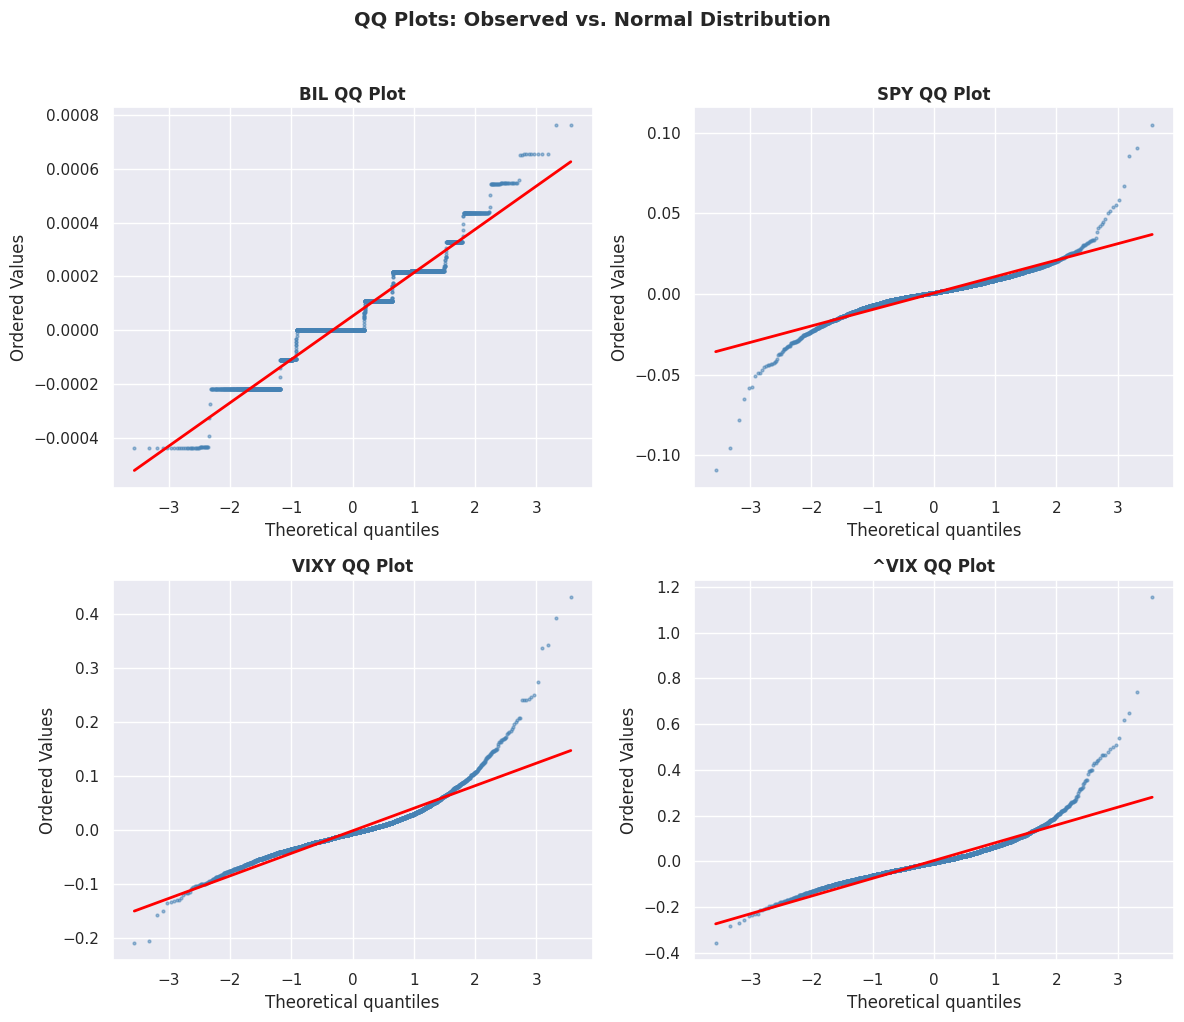

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), df_returns.columns):
    stats.probplot(df_returns[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'{col} QQ Plot', fontsize=12, fontweight='bold')
    ax.get_lines()[0].set(markersize=2, alpha=0.5, color='steelblue')
    ax.get_lines()[1].set(color='red', linewidth=2)

plt.suptitle('QQ Plots: Observed vs. Normal Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The QQ plots make the fat tail problem impossible to ignore.

BIL shows a staircase pattern rather than a smooth curve, which reflects the discrete nature of its tiny returns (short-term Treasury yields move in very small, fixed increments). It deviates from normal, but in a way that is irrelevant for signal processing since we will never filter BIL.

SPY shows the classic equity pattern: both tails curve away from the red line, with the left tail (losses) pulling further down and the right tail (gains) pushing further up than a normal distribution predicts. The isolated points at -0.10 and +0.10 are the extreme events (likely COVID-era moves) that sit far outside the theoretical quantiles.

VIXY and VIX are the most dramatic. Both show severe right-tail divergence: the points curve sharply upward and away from the reference line at the right end. VIX daily changes reaching 1.15 at a theoretical quantile of about 3.5 is extraordinary. A normal distribution would place the probability of such a move at essentially zero. The left tails also diverge, but the asymmetry is clear: upward explosions are far more extreme than downward moves.

This visual is worth remembering when we get to the advanced signal processing techniques. A Kalman filter tuned for Gaussian noise will treat a COVID-era VIX spike as a measurement error to be smoothed away. But that spike is precisely the event our VIXY tail hedge strategy needs to capture. Understanding your data's distribution is not optional: it determines whether a filter helps or hurts your strategy.

## Section 3: Stationarity

Stationarity is one of the most important concepts in time series analysis, and it is an assumption that underpins nearly every signal processing technique we will use in this chapter. A stationary series has statistical properties (mean, variance, autocorrelation) that do not change over time. A non-stationary series has properties that drift, trend, or shift.

Why does this matter for signal processing? Filters like ARIMA, Fourier transforms, and wavelets all assume, to varying degrees, that the statistical structure of the data is stable. If you apply a filter calibrated on one regime to data from a different regime, the filter output is unreliable. This is not a theoretical concern: equity prices trend upward over time (non-stationary), while returns fluctuate around a roughly stable mean (stationary). Choosing to work with prices versus returns is itself a stationarity decision.

In this section, we will test our case study data for stationarity using the Augmented Dickey-Fuller (ADF) test, and visually confirm the difference between stationary and non-stationary series. This will tell us which of our series are appropriate inputs for the filtering techniques in Notebooks 6.2 and 6.3.

### 3.1 Visual Comparison: Prices vs. Returns

The simplest way to understand stationarity is to see it. We plot SPY prices and SPY returns side by side. Prices trend upward over our sample period. Returns fluctuate around zero with no obvious trend. The difference is immediately visible, and it is the difference between a series that violates filter assumptions and one that does not.

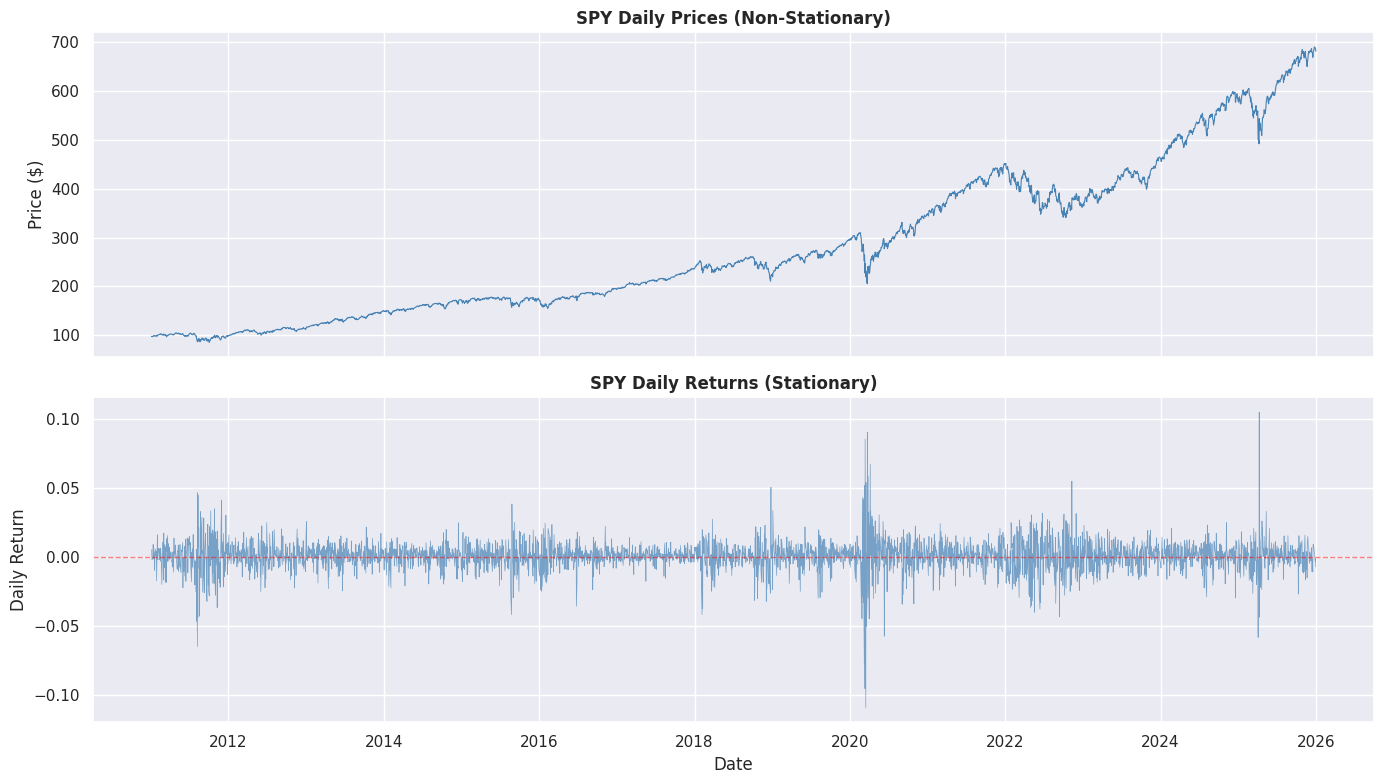

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# SPY Prices
axes[0].plot(df_prices['SPY'], color='steelblue', linewidth=0.8)
axes[0].set_title('SPY Daily Prices (Non-Stationary)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')

# SPY Returns
axes[1].plot(df_returns['SPY'], color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('SPY Daily Returns (Stationary)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Daily Return')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

The contrast is stark. SPY prices in the top panel trend from roughly $100 to nearly $700 over the sample period. There is no stable mean, no stable variance, and the level in 2025 has nothing in common with the level in 2011. This is a textbook non-stationary series.

SPY returns in the bottom panel tell a different story. They fluctuate around the red zero line with no visible trend. The mean is roughly stable across the full sample. However, notice that the variance is not perfectly constant: the cluster of extreme moves around March 2020 and the spike in late 2025 show periods of elevated volatility. This is called volatility clustering, and while returns are stationary in the mean, the time-varying volatility is something to be aware of when calibrating filters.

This visual makes the stationarity decision concrete. If you feed SPY prices into a Fourier transform, it will waste most of its energy modeling the upward trend rather than finding any cyclical patterns. If you feed SPY returns, the filter can focus on the structure (if any) in the fluctuations around zero.

### 3.2 The Augmented Dickey-Fuller Test

The Augmented Dickey-Fuller (ADF) test is the standard statistical test for stationarity. The null hypothesis is that the series has a unit root (is non-stationary). A low p-value (below 0.05) means we reject the null and conclude the series is stationary.

We test both prices and returns for all four instruments. This gives us a clear picture of which series need transformation before filtering.

In [23]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    """Run ADF test and return formatted results."""
    # The ADF test cannot process non-finite values. When returns are built
    # with pct_change, any zero in the prior price produces inf, and
    # dropna() does not remove inf. The result is that adfuller silently
    # accepts the series and then crashes inside its regression step.
    # We replace inf and -inf with NaN first, then drop all non-finite
    # values in one pass. This is defensive cleaning, not a transformation
    # of the data: it only removes observations the test could not have
    # used anyway.
    clean_series = series.replace([np.inf, -np.inf], np.nan).dropna()
    result = adfuller(clean_series, autolag='AIC')
    return {
        'Series': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Lags Used': result[2],
        'Stationary?': 'Yes' if result[1] < 0.05 else 'No'
    }

# Test prices
print("ADF Test on PRICES")
print("=" * 70)
price_results = [adf_test(df_prices[col], col) for col in df_prices.columns]
df_adf_prices = pd.DataFrame(price_results).set_index('Series')
print(df_adf_prices.to_string())

print("\n")

# Test returns
print("ADF Test on RETURNS")
print("=" * 70)
return_results = [adf_test(df_returns[col], col) for col in df_returns.columns]
df_adf_returns = pd.DataFrame(return_results).set_index('Series')
print(df_adf_returns.to_string())

ADF Test on PRICES
        ADF Statistic  p-value  Lags Used Stationary?
Series                                               
BIL            0.7916   0.9915         30          No
SPY            1.8716   0.9985         28          No
VIXY          -2.7376   0.0678         30          No
^VIX          -6.2325   0.0000          9         Yes


ADF Test on RETURNS
        ADF Statistic  p-value  Lags Used Stationary?
Series                                               
BIL           -1.1644   0.6887         30          No
SPY          -13.3976   0.0000         26         Yes
VIXY         -63.7252   0.0000          0         Yes
^VIX         -26.3631   0.0000          6         Yes


The ADF test works by fitting a regression that asks a specific question: does the previous value of the series help predict the change in the series in a way that pulls it back toward a mean? The test statistic (ADF Statistic) measures the strength of this "pull-back" effect. A large negative value means the series has a strong tendency to revert, which is evidence of stationarity. A value near zero or positive means there is no pull-back tendency, which is consistent with a random walk (non-stationary).

The p-value tells us whether to reject the null hypothesis. The null hypothesis of the ADF test is that the series IS non-stationary (it has a unit root). So:

- **Low p-value (below 0.05)**: Reject the null. The series is stationary.
- **High p-value (above 0.05)**: Fail to reject the null. We cannot conclude the series is stationary.

This is easy to mix up. Remember: a low p-value is the "good" result if you are hoping for stationarity.

The "Lags Used" column matters because financial data often has short-term autocorrelation. The ADF test includes lagged terms to account for this. If you ignore autocorrelation in the data, the test can produce misleading results. The autolag="AIC" setting we used lets the test automatically select the number of lags that best balances model fit and complexity using the Akaike Information Criterion. More lags mean the test is accounting for more complex short-term dynamics. SPY prices needed 28 lags, while VIX only needed 9, reflecting different autocorrelation structures.

Now, looking at the results:

**Prices:** SPY and BIL prices are non-stationary (high p-values, we cannot reject the unit root null). This confirms what we saw visually: prices trend and have no stable mean. VIXY prices are borderline (p=0.068), just missing the 0.05 threshold. This reflects the competing forces in VIXY: it has a strong downward drift from contango decay, but it also spikes during crises, making it a difficult series for the ADF test to characterize cleanly.

The standout result is VIX: its price levels are stationary (p=0.000) with an ADF statistic of -6.23. This makes intuitive sense. VIX is a mean-reverting index. It spikes during market stress and then reverts back toward a long-run average. This mean-reverting property is exactly why our VIXY strategy uses VIX as a signal source, and it also means VIX levels are valid inputs for filters and ARIMA models without differencing. This will be important in Notebook 6.2.

**Returns:** SPY, VIXY, and VIX returns are all stationary with extremely large negative ADF statistics (SPY at -13.40, VIXY at -63.73, VIX at -26.36). These are emphatic rejections of the null. Differencing (taking returns) removes the non-stationarity in prices.

BIL returns are the surprise: the ADF test fails to reject non-stationarity (p=0.689). This is a quirk of BIL's extremely low variance and discrete return structure. The returns are so small and concentrated around a few fixed values that the ADF test with 30 lags struggles to distinguish them from a random walk. In practice, BIL is not a series we will ever filter, so this result is a curiosity rather than a concern.

The practical takeaway: when we apply signal processing techniques in the notebooks that follow, we should work with returns for SPY and VIXY, but we can work directly with VIX levels since they are already stationary. This is a meaningful advantage because, as we will discuss in Section 5, differencing to achieve stationarity destroys long-range memory in the data.

### 3.3 VIX: A Mean-Reverting Series

The ADF result for VIX deserves special attention because it has direct implications for our strategy. VIX being stationary means it has a stable long-run mean that it gravitates toward. We can visualize this by plotting VIX levels with a long-run average overlaid. This mean-reverting behavior is the foundation of our VIXY tail hedge signal: when realized volatility exceeds the VIX moving average, something unusual is happening and we want protection.

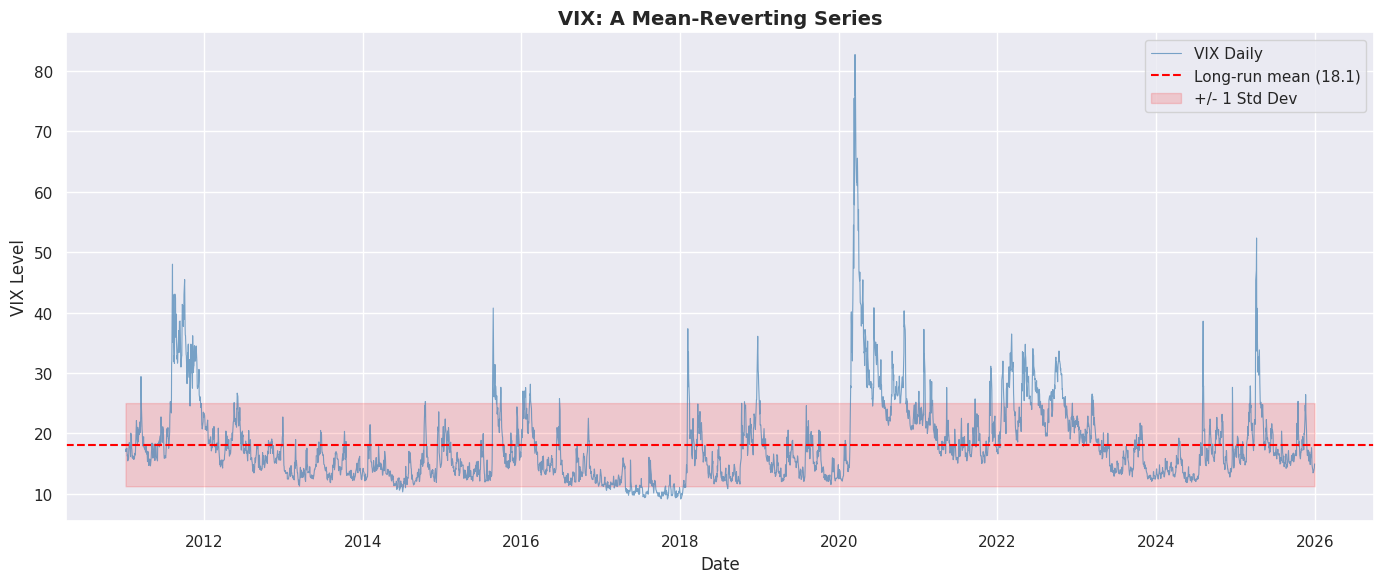

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_prices['^VIX'], color='steelblue', linewidth=0.8, alpha=0.7, label='VIX Daily')
ax.axhline(y=df_prices['^VIX'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Long-run mean ({df_prices["^VIX"].mean():.1f})')
ax.fill_between(df_prices.index,
                df_prices['^VIX'].mean() - df_prices['^VIX'].std(),
                df_prices['^VIX'].mean() + df_prices['^VIX'].std(),
                alpha=0.15, color='red', label=f'+/- 1 Std Dev')

ax.set_title('VIX: A Mean-Reverting Series', fontsize=14, fontweight='bold')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

This chart illustrates exactly what the ADF test confirmed statistically. VIX has a long-run mean of approximately 18.1 (the red dashed line), and the series repeatedly gravitates back toward it. The pink band shows one standard deviation above and below the mean. During calm markets (2017, late 2023-2024), VIX settles near or below the mean. During stress events, it spikes violently above it: the 2011 debt ceiling crisis, the 2015 China devaluation, COVID in early 2020 (reaching above 80), and the 2025 spike.

The critical observation is the asymmetry. VIX spikes up fast and reverts down slowly. It can double or triple in a matter of days, but it takes weeks or months to drift back to its long-run average. This asymmetric mean-reversion is what makes VIX useful as a signal source: a VIX spike is a clear, detectable event, and the reversion that follows is relatively predictable.

For our VIXY strategy, this chart shows why a moving average on VIX is a sensible signal. The 90-day SMA acts as a trailing estimate of the long-run mean, adapting as conditions change. When realized volatility exceeds that moving average, VIX is elevated relative to recent history, and we want tail protection. The stationarity of VIX is what makes this logic work: because VIX reverts to a mean, comparing current levels to a trailing average is a meaningful comparison. If VIX were non-stationary (trending like SPY prices), a moving average crossover would be much less informative.

## Section 4: Trends and Seasonality

Signal processing techniques like Fourier transforms and wavelets attempt to decompose a time series into components: trend, seasonal patterns, and residual noise. Before we apply those techniques in Notebook 6.3, it is worth asking whether our data actually has meaningful trends and seasonality that can be separated.

Time series decomposition is a formal method for splitting a series into these components. The idea is straightforward: if you can identify and remove the trend and any repeating seasonal pattern, what remains (the residual) is what your filter will need to work with. If the trend and seasonality explain most of the variation, the residual is small and well-behaved. If they explain very little, decomposition has not bought you much.

We will apply seasonal decomposition to VIX, since it is the stationary series most likely to have interesting structure, and briefly examine whether SPY returns show any day-of-week seasonality.

### 4.1 Seasonal Decomposition of VIX

We use the statsmodels seasonal_decompose function with a period of 252 trading days (one year) to separate VIX into trend, seasonal, and residual components. The multiplicative model is appropriate here since VIX's volatility scales with its level (spikes are larger when VIX is higher).

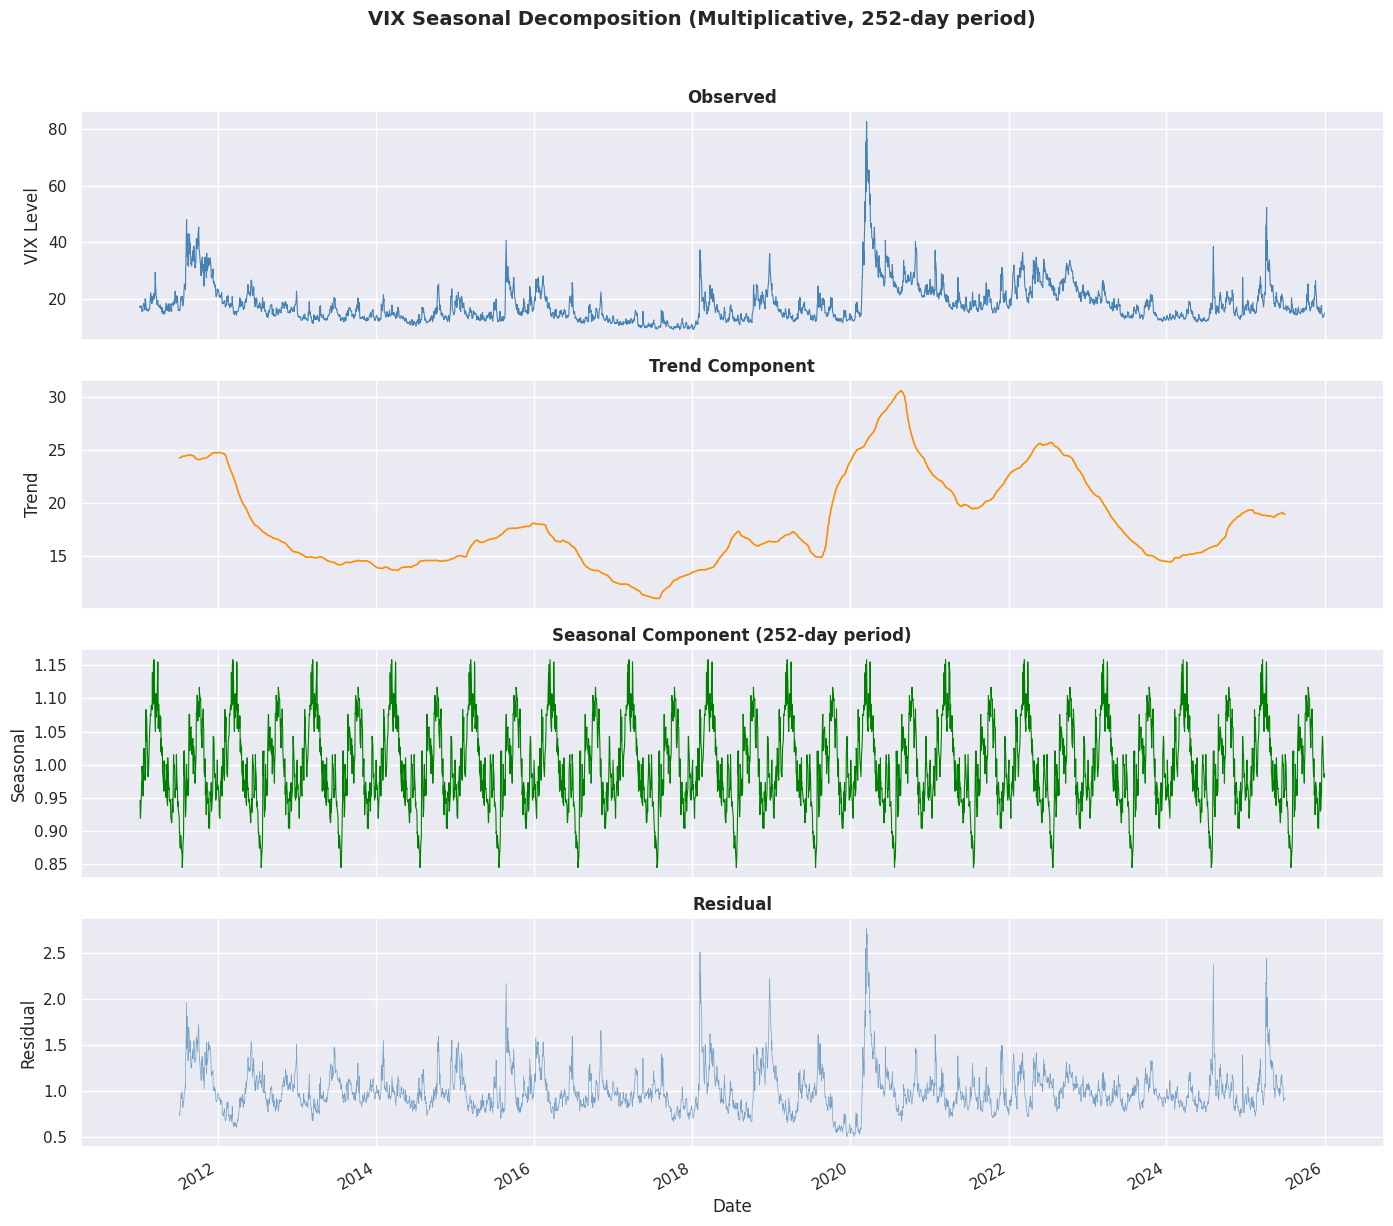

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose VIX into trend, seasonal, and residual components
# model='multiplicative': components multiply together (observed = trend * seasonal * residual)
#   This is appropriate when the amplitude of fluctuations scales with the level,
#   which is the case for VIX (spikes are larger when VIX is already elevated)
# period=252: one trading year. This tells the algorithm to look for patterns
#   that repeat every 252 trading days (approximately one calendar year)
decomposition = seasonal_decompose(df_prices['^VIX'], model='multiplicative', period=252)

# Plot all four components stacked vertically with a shared x-axis
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Panel 1: Original observed series (for reference)
decomposition.observed.plot(ax=axes[0], color='steelblue', linewidth=0.8)
axes[0].set_title('Observed', fontsize=12, fontweight='bold')
axes[0].set_ylabel('VIX Level')

# Panel 2: Trend component (extracted via centered moving average)
# Note: this will have NaN values at both edges (first and last 126 days)
# because a 252-day centered MA cannot compute values at the boundaries
decomposition.trend.plot(ax=axes[1], color='darkorange', linewidth=1.2)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')

# Panel 3: Seasonal component (repeating annual pattern)
# Values oscillate around 1.0 in a multiplicative model
# A value of 1.10 means VIX is 10% above trend at that point in the annual cycle
decomposition.seasonal.plot(ax=axes[2], color='green', linewidth=0.8)
axes[2].set_title('Seasonal Component (252-day period)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')

# Panel 4: Residual (what is left after removing trend and seasonal)
# In a well-behaved decomposition, this would look like random noise around 1.0
decomposition.resid.plot(ax=axes[3], color='steelblue', linewidth=0.5, alpha=0.7)
axes[3].set_title('Residual', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.suptitle('VIX Seasonal Decomposition (Multiplicative, 252-day period)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The decomposition reveals some interesting patterns, but also highlights the limitations of this approach for financial data.

**Trend component** (second panel): The trend captures the slow-moving average level of VIX over time. It drifts between roughly 13 and 30, reflecting the broad volatility regimes we can see in the original series. The COVID period clearly pushed the trend to its highest level around 30. Notice the gaps at the edges: the 252-day moving average used to extract the trend cannot compute values for the first and last 126 days. This is an early preview of the **boundary effects** problem we will discuss extensively in Notebook 6.3.

**Seasonal component** (third panel): The seasonal pattern oscillates between roughly 0.85 and 1.15, meaning the decomposition found a repeating annual pattern that raises or lowers VIX by up to 15% relative to its trend. There is some academic research suggesting VIX tends to be higher in the fall (around September-October) and lower in mid-summer, which would be consistent with this pattern. However, the seasonal component is noisy and the amplitude is modest. It is not clear that this seasonality is strong enough or stable enough to build a trading signal around.

**Residual** (bottom panel): This is what remains after removing the trend and seasonal components. Ideally, a good decomposition leaves a residual that looks like random noise centered around 1.0 (in a multiplicative model). Our residual is not well-behaved. The spikes reaching 2.0 to 2.5 during crisis periods (2011, 2015, 2018, 2020, 2025) show that the decomposition could not capture the most important feature of VIX: sudden, extreme spikes. These spikes are not seasonal or trend-related. They are event-driven, and no fixed-period decomposition can account for them.

**The takeaway for signal processing:** Seasonal decomposition is a useful exploratory tool, but for VIX, the most important variation (crisis spikes) ends up in the residual rather than being explained by the trend or seasonal components. This tells us that techniques designed to extract fixed cycles (like Fourier transforms) are unlikely to capture the dynamics that matter most for our strategy. The spikes that drive our VIXY hedge signal are irregular events, not periodic patterns.

**Practical guidance:** In professional quant finance, seasonal decomposition is rarely used as a core part of a trading strategy. You will see it more often in economic research and in exploratory analysis, which is exactly how we are using it here. It can be useful for identifying calendar effects (sell in May, January effect) or for deseasonalizing a series before modeling, but those applications are more common in macro and fixed income strategies than in equity or volatility trading. If a strategy's edge depends on a seasonal pattern extracted by this method, you should be skeptical: seasonal patterns in markets tend to weaken or disappear once they become widely known. For our VIXY strategy, the decomposition confirms what we suspected. The signal we care about (VIX spikes) is event-driven and irregular, not seasonal. A moving average on VIX captures what we need without the added complexity of decomposition.

### 4.2 Day-of-Week Effects in Returns

One of the most studied seasonal patterns in finance is the day-of-week effect: the idea that certain days of the week produce systematically higher or lower returns. Monday has historically been associated with negative returns ("the Monday effect"), while Friday tends to be positive. These effects have been documented in academic research going back decades, though the evidence for their persistence in modern markets is mixed.

This is relevant to signal processing because Fourier transforms can detect periodic patterns at specific frequencies. If a strong weekly cycle exists, Fourier analysis would find it. Let us check whether any day-of-week pattern exists in our SPY returns.

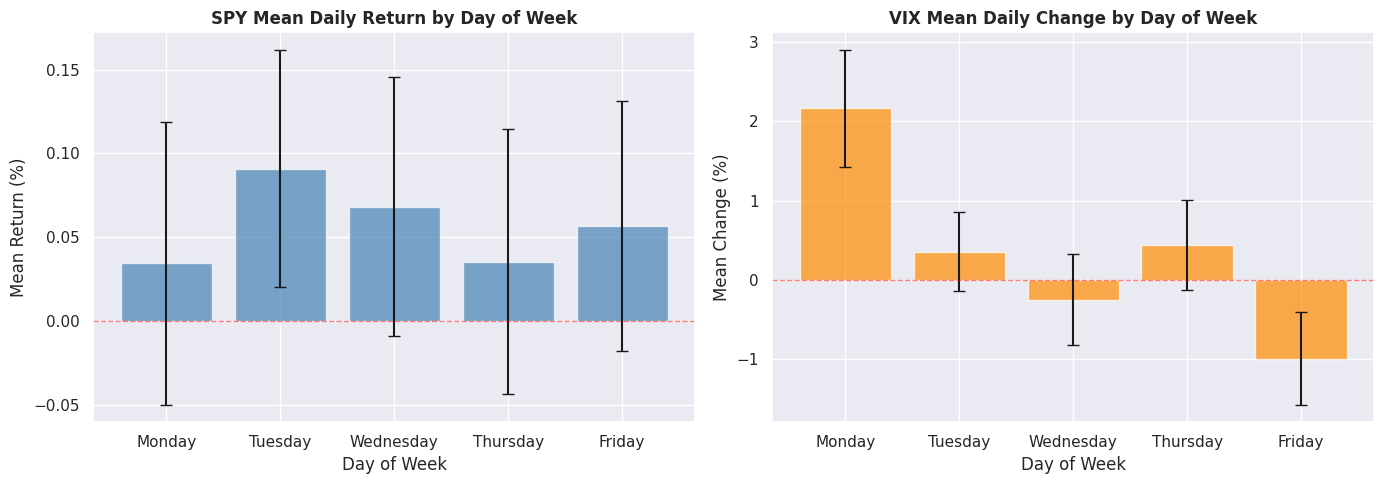

SPY Mean Daily Return by Day of Week
Monday       Mean:   0.034%   Std Err:  0.043%   n=705
Tuesday      Mean:   0.091%   Std Err:  0.036%   n=775
Wednesday    Mean:   0.068%   Std Err:  0.040%   n=773
Thursday     Mean:   0.035%   Std Err:  0.040%   n=759
Friday       Mean:   0.057%   Std Err:  0.038%   n=758


In [16]:
# Create a copy of SPY and VIX returns for day-of-week analysis
df_dow = df_returns[['SPY', '^VIX']].copy()

# Extract the day name (Monday, Tuesday, etc.) from the datetime index
# This uses the pandas .day_name() method on the DatetimeIndex
df_dow['DayOfWeek'] = df_dow.index.day_name()

# Define the correct display order (pandas would otherwise sort alphabetically)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# --- Calculate SPY statistics grouped by day of week ---
# .agg() lets us compute multiple statistics in one call
dow_stats = df_dow.groupby('DayOfWeek')['SPY'].agg(['mean', 'std', 'count'])

# Calculate standard error of the mean: std / sqrt(n)
# This tells us how precisely we have estimated the true mean for each day
dow_stats['se'] = dow_stats['std'] / np.sqrt(dow_stats['count'])

# Reorder rows to match our Monday-Friday display order
dow_stats = dow_stats.reindex(dow_order)

# --- Create side-by-side bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SPY mean return by day of week
# yerr adds error bars: 1.96 * standard error gives 95% confidence interval
# Multiply by 100 to display as percentage
axes[0].bar(dow_stats.index, dow_stats['mean'] * 100,
            yerr=dow_stats['se'] * 1.96 * 100,
            color='steelblue', alpha=0.7, capsize=4)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title('SPY Mean Daily Return by Day of Week', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mean Return (%)')
axes[0].set_xlabel('Day of Week')

# Repeat the same analysis for VIX daily changes
dow_vix = df_dow.groupby('DayOfWeek')['^VIX'].agg(['mean', 'std', 'count'])
dow_vix['se'] = dow_vix['std'] / np.sqrt(dow_vix['count'])
dow_vix = dow_vix.reindex(dow_order)

axes[1].bar(dow_vix.index, dow_vix['mean'] * 100,
            yerr=dow_vix['se'] * 1.96 * 100,
            color='darkorange', alpha=0.7, capsize=4)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('VIX Mean Daily Change by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Change (%)')
axes[1].set_xlabel('Day of Week')

plt.tight_layout()
plt.show()

# --- Print numerical summary ---
# The chart gives the visual intuition; the table gives precise values
print("SPY Mean Daily Return by Day of Week")
print("=" * 50)
for day in dow_order:
    row = dow_stats.loc[day]
    print(f"{day:<12} Mean: {row['mean']*100:>7.3f}%   Std Err: {row['se']*100:>6.3f}%   n={int(row['count'])}")

The error bars in these charts are 95% confidence intervals, and they tell the real story. While there are visual differences between days (Tuesday has the highest mean SPY return at 0.091%, Monday the lowest at 0.034%), every single error bar crosses zero. This means none of these differences are statistically significant. We cannot conclude that any day of the week produces reliably different returns from any other day.

The VIX chart on the right is more visually striking. Monday shows a large positive mean change (about 2.1%) and Friday shows a negative mean change (about -1.0%). This pattern has a logical explanation: VIX tends to rise going into the weekend (reflecting uncertainty over two days of no trading) and fall on Fridays (as weekend decay in options premiums gets priced in). However, look at the error bars. They are enormous relative to the means, particularly for Monday. The standard errors are so large that we cannot distinguish these patterns from random variation with any confidence.

**Practical guidance:** Day-of-week effects are one of the most studied "anomalies" in finance, and the consensus among practitioners is that they are either too small to trade profitably or have been arbitraged away in modern markets. If a Fourier transform applied to daily returns found a strong weekly cycle, you should be skeptical rather than excited. In practice, professional quants rarely build strategies around calendar effects alone. Where these effects do have value is as a secondary filter or as a control variable in a broader model. For example, if you are building an ML-based strategy (Chapters 13-14), including day-of-week as a feature might marginally improve predictions, but it will not be the primary driver of alpha. For our VIXY strategy, there is nothing here that would improve the signal.

## Section 5: Autocorrelation and Partial Autocorrelation

Autocorrelation is arguably the most important diagnostic for signal processing. It answers a simple but critical question: does the past predict the future? More precisely, is there a statistical relationship between a value in the series and the values that came before it?

If a series has significant autocorrelation, there is structure in the data that a filter can potentially extract or exploit. If there is no autocorrelation, the series is essentially random from one observation to the next, and no amount of filtering will create a useful signal from it. This is the single most important test for setting realistic expectations about what signal processing can do for your data.

We use two complementary tools:

- **Autocorrelation Function (ACF)**: Measures the correlation between the series and lagged versions of itself. The ACF at lag 5, for example, measures how correlated today's value is with the value from 5 days ago. The ACF includes both direct effects and indirect effects (a correlation at lag 2 might exist only because lag 1 is correlated with both today and lag 2).
- **Partial Autocorrelation Function (PACF)**: Measures the correlation at a specific lag after removing the effects of all shorter lags. This isolates the direct relationship at each lag. If the PACF is significant at lag 3 but not at lags 1 or 2, it means there is a direct relationship with three days ago that does not flow through the intervening days.

Together, ACF and PACF tell us what kind of memory structure exists in the data, and they are essential for selecting parameters in ARIMA models (Notebook 6.2). Most importantly for our purposes, they tell us which of our series have structure worth filtering and which do not.

### 5.1 ACF and PACF of SPY Returns

We start with SPY returns because this is the series most readers will want to filter. If daily equity returns have significant autocorrelation, signal processing techniques could potentially extract a tradeable signal. If they do not, filtering returns is unlikely to help.

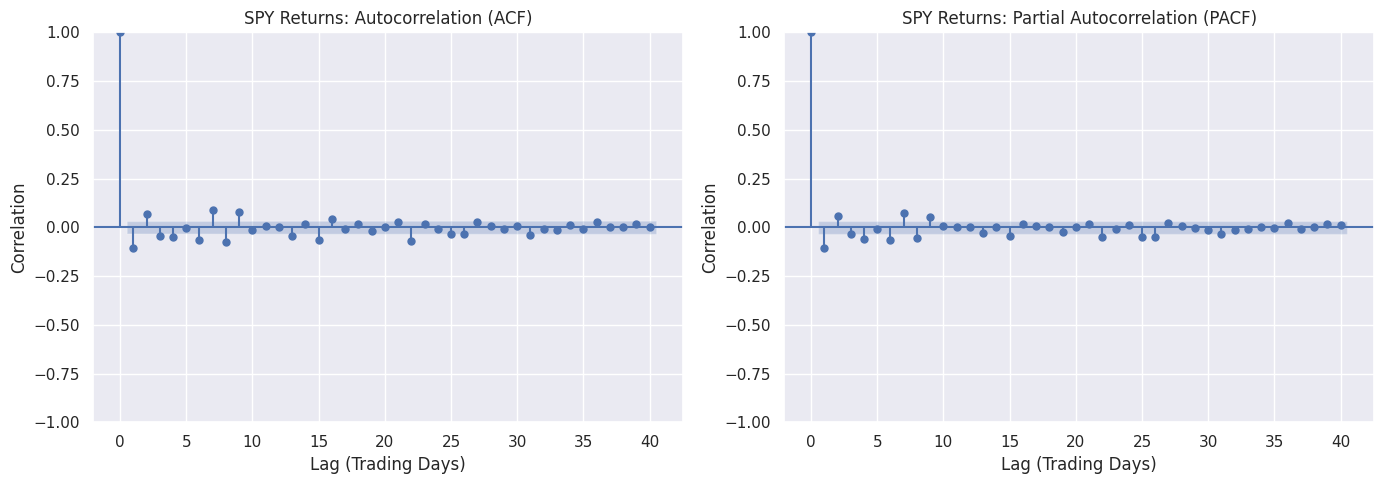

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- ACF and PACF for SPY Daily Returns ---
# We plot 40 lags (roughly 2 months of trading days) to look for
# any short-to-medium term structure in the autocorrelation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF: shows total correlation at each lag (direct + indirect effects)
# The blue shaded region is the 95% confidence band. Any bar that stays
# inside this band is NOT statistically different from zero.
# alpha=0.05 draws the 95% confidence interval
# lags=40 checks correlations up to 40 trading days back
plot_acf(df_returns['SPY'].dropna(), lags=40, ax=axes[0], alpha=0.05,
         title='SPY Returns: Autocorrelation (ACF)')

# PACF: shows the direct correlation at each lag after removing
# the influence of all shorter lags. This isolates the "pure"
# relationship at each specific lag distance.
plot_pacf(df_returns['SPY'].dropna(), lags=40, ax=axes[1], alpha=0.05,
          title='SPY Returns: Partial Autocorrelation (PACF)')

# Improve readability
for ax in axes:
    ax.set_xlabel('Lag (Trading Days)')
    ax.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

This is one of the most important charts in the entire notebook. The tall spike at lag 0 is always 1.0 by definition (any series is perfectly correlated with itself). What matters is everything after that.

Both the ACF and PACF show almost no significant autocorrelation in SPY daily returns. Nearly every bar falls within the blue shaded confidence band, meaning we cannot distinguish it from zero. There are a couple of bars that barely poke outside the band (possibly around lags 2 and 8 in the ACF), but with 40 lags tested at the 95% confidence level, we would expect about 2 false positives by pure chance (40 * 0.05 = 2). These tiny exceedances are almost certainly noise.

What does this mean for signal processing? It means there is essentially no linear predictive structure in daily SPY returns. Today's return tells you almost nothing about tomorrow's return. There is no momentum signal, no mean-reversion signal, and no cyclical pattern hiding in the autocorrelation structure at any lag from 1 to 40 days.

This is the single most important result for setting expectations about what signal processing can do for equity returns. If there is no autocorrelation, there is nothing for a linear filter to extract. Applying a Kalman filter, Fourier transform, or wavelet denoiser to SPY returns will not uncover a hidden signal because there is no hidden signal to uncover. The efficient market hypothesis would predict exactly this result: in a liquid, heavily traded market like the S&P 500, simple linear patterns in returns get arbitraged away quickly.

This does NOT mean SPY is completely unpredictable. It means the predictability, if any, lives in nonlinear relationships, cross-asset signals, other signals derived from prices or returns, or in the volatility of returns rather than the returns themselves. That is exactly what our VIXY strategy exploits: it does not try to predict SPY returns directly. Instead, it monitors volatility conditions and adjusts hedging accordingly.

### 5.2 ACF and PACF of VIX Levels

Now we look at VIX, which we expect to tell a very different story. VIX is a mean-reverting, stationary series. Mean-reversion implies that elevated values tend to be followed by declines, and low values tend to be followed by increases. This should show up as strong, slowly decaying autocorrelation in the ACF.

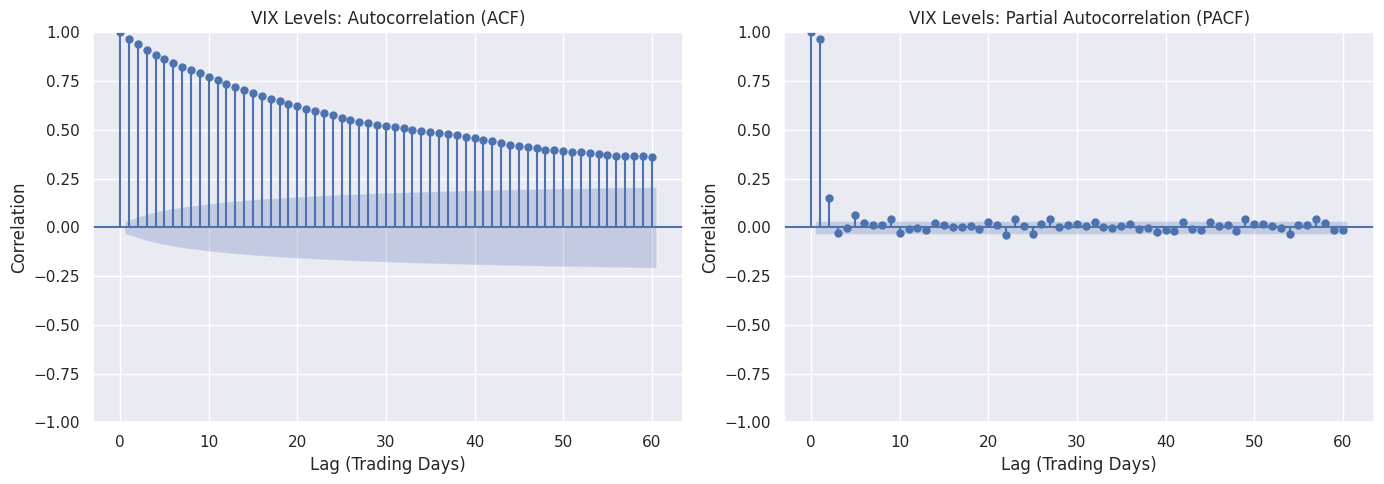

In [18]:
# --- ACF and PACF for VIX Levels ---
# We use VIX levels (not returns) because the ADF test in Section 3
# confirmed that VIX levels are already stationary. Working with levels
# preserves the autocorrelation structure we want to examine.
# We extend to 60 lags (roughly 3 months) since VIX is known
# for persistent, slowly decaying autocorrelation.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF: we expect strong positive autocorrelation that decays slowly,
# consistent with a mean-reverting process where today's level is
# highly informative about tomorrow's level
plot_acf(df_prices['^VIX'].dropna(), lags=60, ax=axes[0], alpha=0.05,
         title='VIX Levels: Autocorrelation (ACF)')

# PACF: we expect a large spike at lag 1 and then a sharp dropoff.
# This pattern (strong lag-1, minimal after) suggests an AR(1)-like
# process, which is the simplest mean-reverting model.
plot_pacf(df_prices['^VIX'].dropna(), lags=60, ax=axes[1], alpha=0.05,
          title='VIX Levels: Partial Autocorrelation (PACF)')

for ax in axes:
    ax.set_xlabel('Lag (Trading Days)')
    ax.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

The contrast with SPY returns could not be more dramatic.

The ACF (left panel) shows exactly the pattern we predicted: strong positive autocorrelation that decays slowly over time. At lag 1, the correlation is approximately 0.98, meaning today's VIX level is almost perfectly correlated with yesterday's. Even at lag 60 (three months of trading days), the autocorrelation is still around 0.37 and clearly significant (well above the confidence band). This slow decay is the signature of a persistent, mean-reverting process. VIX does not jump randomly from day to day. It moves in regimes: when volatility is elevated, it tends to stay elevated for a while before gradually reverting. When it is low, it tends to stay low.

The PACF (right panel) tells us something equally important. There is a massive spike at lag 1 (the direct relationship between today and yesterday), a smaller but significant spike at lag 2 (around 0.15), and then everything collapses into the confidence band. This pattern is characteristic of a low-order autoregressive process, likely AR(1) or AR(2). In plain language: once you know yesterday's VIX and perhaps the day before, knowing what VIX was 10 or 30 days ago adds almost no additional predictive information. The memory in VIX is strong but it flows through the most recent observations.

This has direct implications for signal processing:

- **ARIMA modeling** (Notebook 6.2): The ACF/PACF pattern suggests an ARIMA(1,0,0) or ARIMA(2,0,0) model on VIX levels would be a natural fit. The slow ACF decay combined with sharp PACF cutoff after lag 1-2 is the textbook pattern for a low-order AR process. This is exactly how we will select ARIMA parameters in the next notebook.
- **Kalman filtering** (Notebook 6.3): The strong autocorrelation means a Kalman filter has genuine structure to work with. It can estimate the underlying VIX state with confidence because today's observation is highly informative about tomorrow's.
- **Moving averages**: Our 90-day SMA on VIX works precisely because of this slow-decaying autocorrelation. If VIX had no memory (like SPY returns), a moving average would just be averaging noise.

**Practical guidance:** This is the kind of series where signal processing has a legitimate shot at adding value. Unlike SPY returns where autocorrelation is essentially zero, VIX has rich, persistent structure that filters can exploit. When practitioners talk about signal processing "working" in finance, they are usually working with series that look like this: volatility measures, interest rates, credit spreads, and other mean-reverting quantities. If your series does not have significant autocorrelation, save yourself the effort and skip the advanced filters.

### 5.3 ACF and PACF of SPY Realized Volatility

We showed that SPY returns have no meaningful autocorrelation, but VIX levels have very strong autocorrelation. There is an important bridge between these two results: the volatility of SPY returns. While returns themselves are unpredictable, the magnitude of returns (how volatile the market is) tends to cluster. Large moves are followed by large moves, and calm periods are followed by calm periods. This phenomenon is called volatility clustering, and it is one of the most robust empirical facts in finance.

This matters for our VIXY strategy directly. The strategy compares SPY's 10-day realized volatility against the VIX moving average. If realized volatility has strong autocorrelation (like VIX), that signal has persistence and is worth filtering. If it does not, the signal is noisy and filtering may not help.

We calculate realized volatility as the rolling 10-day standard deviation of SPY returns, annualized to match the VIX scale (multiplied by the square root of 252), just as we do in the strategy code.

In [19]:
# --- Calculate SPY realized volatility ---
# This matches the calculation in vixy_tail_hedge.py (line 50):
#   10-day rolling standard deviation of daily returns, annualized
# We annualize by multiplying by sqrt(252) because:
#   - Standard deviation scales with the square root of time
#   - There are approximately 252 trading days per year
#   - VIX is quoted in annualized terms, so we need the same scale
spy_realized_vol = (df_returns['SPY']
                    .rolling(window=10)
                    .std()
                    * np.sqrt(252)
                    * 100)  # Convert to percentage to match VIX scale

# Drop the initial NaN values from the rolling window
spy_realized_vol = spy_realized_vol.dropna()

print(f"SPY Realized Volatility (10-day, annualized)")
print(f"Date range: {spy_realized_vol.index[0].strftime('%Y-%m-%d')} to "
      f"{spy_realized_vol.index[-1].strftime('%Y-%m-%d')}")
print(f"Mean: {spy_realized_vol.mean():.2f}%")
print(f"Min:  {spy_realized_vol.min():.2f}%")
print(f"Max:  {spy_realized_vol.max():.2f}%")

SPY Realized Volatility (10-day, annualized)
Date range: 2011-01-19 to 2025-12-31
Mean: 14.21%
Min:  2.01%
Max:  112.29%


The realized volatility ranges from a calm 2.01% to an extreme 112.29% (almost certainly during the COVID crash in March 2020), with a mean of 14.21%. This mean is close to the long-run VIX average of 18.1 we saw earlier, which makes sense: VIX is the market's expectation of future volatility, and realized volatility is what actually occurred. The two should be in the same neighborhood over long periods.

Now let us see whether this series has the autocorrelation structure that would make it a good candidate for filtering.

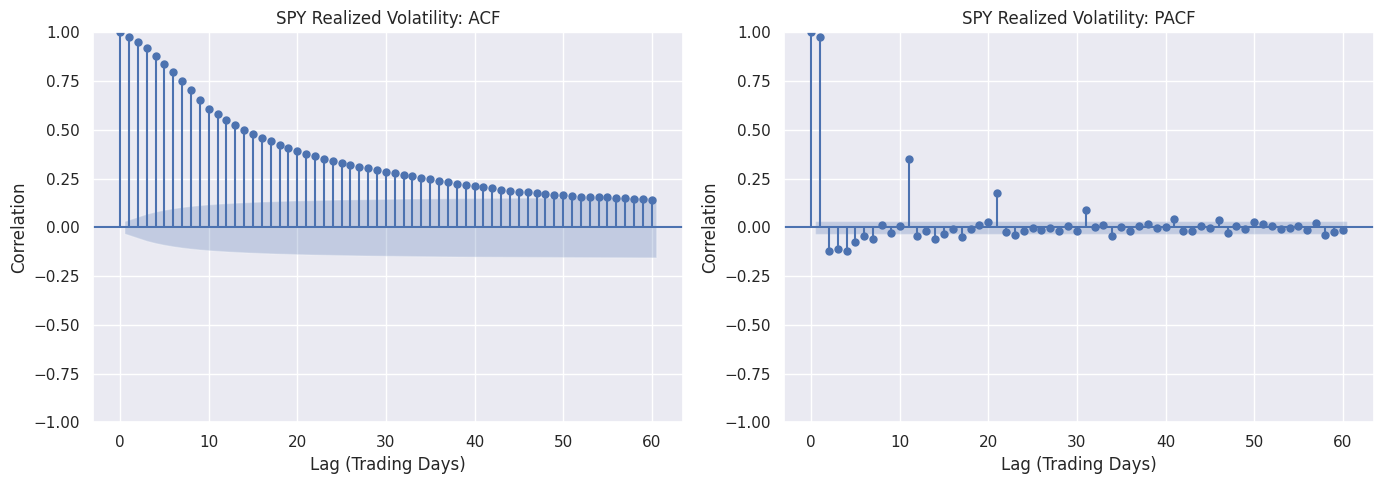

In [20]:
# --- ACF and PACF for SPY Realized Volatility ---
# We use 60 lags (3 months) to match our VIX analysis for comparison.
# If realized vol has similar autocorrelation structure to VIX,
# it would explain why comparing the two (as our VIXY strategy does)
# produces a stable, meaningful signal.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF: if realized vol clusters (large vol followed by large vol),
# we expect strong, slowly decaying positive autocorrelation
plot_acf(spy_realized_vol.dropna(), lags=60, ax=axes[0], alpha=0.05,
         title='SPY Realized Volatility: ACF')

# PACF: tells us the order of the autoregressive structure
# A sharp cutoff after a few lags suggests a low-order AR process
plot_pacf(spy_realized_vol.dropna(), lags=60, ax=axes[1], alpha=0.05,
          title='SPY Realized Volatility: PACF')

for ax in axes:
    ax.set_xlabel('Lag (Trading Days)')
    ax.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

The ACF (left panel) shows the same slowly decaying pattern we saw in VIX, confirming that volatility clustering is very real. Today's realized volatility is strongly correlated with yesterday's (lag 1 near 0.98), and the autocorrelation remains significant even at lag 60 (around 0.13). Volatility regimes persist for weeks and months, not days.

The PACF (right panel) is more complex than what we saw for VIX. There is the expected large spike at lag 1, but also notable spikes around lags 5 and 10, and some significant negative values at lags 2-3. This more complex structure deserves an explanation. Part of it is an artifact of the 10-day rolling window we used to calculate realized volatility. Because each observation shares 9 of its 10 data points with the previous observation, the rolling window mechanically introduces autocorrelation at short lags. The spike at lag 10 in the PACF likely reflects the window length: observation t and observation t-10 share no overlapping data points, so lag 10 captures the "true" direct relationship between non-overlapping volatility estimates.

This is an important cautionary point. When you calculate rolling statistics, the rolling window itself creates autocorrelation that is not present in the underlying data. You need to be careful not to interpret this mechanical autocorrelation as genuine predictive structure. A Kalman filter or ARIMA model applied to rolling realized volatility would partly be modeling the overlap in the rolling window, not just the true volatility dynamics.

Despite that caveat, the overall picture is clear: realized volatility, like VIX, is a highly persistent, autocorrelated series. This is why our VIXY strategy's signal (comparing realized volatility to a VIX moving average) is meaningful. Both inputs have genuine memory, they move in regimes, and when one diverges from the other, that divergence tends to persist long enough to trade on.

**Practical guidance:** This result reinforces the lesson from Sections 5.1 and 5.2. In equity markets, signal processing should be aimed at volatility and risk measures, not at returns directly. Returns are close to a random walk. Volatility is persistent and structured. If you are going to invest the effort in Kalman filters, wavelets, or ARIMA models, apply them to series that look like the VIX and realized volatility plots above, not to series that look like the SPY returns plot. This is where signal processing has its best chance of adding genuine value in a trading context.

## Section 6: Summary and Key Takeaways

This notebook established the statistical foundation for everything that follows in Notebooks 6.2, 6.3, and 6.4. Before we move on to applying signal processing techniques, let us consolidate what we learned about our data and what it means for filtering.

In [21]:
# --- Summary table: which series are filterable? ---
# This table consolidates the key findings from all sections
# into a single reference that readers can come back to when
# deciding whether to apply a technique in later notebooks.

summary_data = {
    'Series': ['SPY Prices', 'SPY Returns', 'SPY Realized Vol',
               'VIX Levels', 'VIX Changes', 'VIXY Returns'],
    'Stationary?': ['No', 'Yes', 'Yes*', 'Yes', 'Yes', 'Yes'],
    'Normal?': ['N/A', 'No (kurtosis=12.9)', 'N/A',
                'N/A', 'No (kurtosis=17.3)', 'No (kurtosis=9.6)'],
    'Autocorrelation?': ['N/A (non-stationary)', 'No (essentially zero)',
                         'Strong (slowly decaying)', 'Strong (slowly decaying)',
                         'Weak', 'Weak'],
    'Filterable?': ['Transform first', 'Unlikely to help', 'Yes - good candidate',
                    'Yes - best candidate', 'Limited value', 'Limited value'],
}

df_summary = pd.DataFrame(summary_data).set_index('Series')

print("Summary: Statistical Properties of Case Study Series")
print("=" * 85)
print("\n* SPY Realized Vol is constructed from a rolling window, which mechanically")
print("  introduces autocorrelation. True underlying persistence is somewhat weaker.\n")
print(df_summary.to_string())

Summary: Statistical Properties of Case Study Series

* SPY Realized Vol is constructed from a rolling window, which mechanically
  introduces autocorrelation. True underlying persistence is somewhat weaker.

                 Stationary?             Normal?          Autocorrelation?           Filterable?
Series                                                                                          
SPY Prices                No                 N/A      N/A (non-stationary)       Transform first
SPY Returns              Yes  No (kurtosis=12.9)     No (essentially zero)      Unlikely to help
SPY Realized Vol        Yes*                 N/A  Strong (slowly decaying)  Yes - good candidate
VIX Levels               Yes                 N/A  Strong (slowly decaying)  Yes - best candidate
VIX Changes              Yes  No (kurtosis=17.3)                      Weak         Limited value
VIXY Returns             Yes   No (kurtosis=9.6)                      Weak         Limited value


This table is your decision-making reference for the rest of Chapter 6. The two right-hand columns are what matter most:

**VIX levels** are the best candidate for signal processing. They are stationary, have strong persistent autocorrelation, and are the primary signal source for our VIXY strategy. In Notebook 6.2, we will fit ARIMA models to VIX. In Notebook 6.3, we will apply Kalman filters, Fourier transforms, and wavelets. VIX gives these techniques genuine structure to work with.

**SPY realized volatility** is also a good candidate, with the caveat that some of its autocorrelation is mechanical (from the rolling window). Filtering or smoothing realized volatility could potentially improve the stability of our strategy signal.

**SPY returns** are unlikely to benefit from signal processing. With essentially zero autocorrelation, there is no linear structure for a filter to extract. This does not mean SPY is useless in a quantitative strategy. It means the edge comes from how you use SPY returns (portfolio construction, risk management, regime detection) rather than from filtering the returns themselves.

**VIX changes and VIXY returns** have weak autocorrelation and heavy tails. Standard linear filters will struggle with these series. If you need to work with them, consider nonlinear approaches or use them as inputs to a broader model rather than filtering them in isolation.

The core lesson from this notebook: know your data before you filter it. The statistical properties we measured here (normality, stationarity, autocorrelation) are not academic exercises. They directly determine which signal processing techniques have a chance of working and which are a waste of effort. In the notebooks that follow, we will put this to the test.

In [22]:
# --- Scratch diagnostic: locate inf values in df_returns and trace their cause ---

# Step 1: count infs per column. We use np.isinf rather than comparing to np.inf
# directly so we catch both +inf and -inf in one pass.
print("Infinite values per column in df_returns:")
print(np.isinf(df_returns).sum())
print()

# Step 2: for any column that has infs, find the specific dates and look at
# the prices on those dates and the day before. pct_change divides today's
# change by the prior price, so a zero (or vanishingly small) prior price
# is what produces inf. Showing both rows makes the cause obvious.
inf_cols = df_returns.columns[np.isinf(df_returns).any()]

if len(inf_cols) == 0:
    print("No infinite values found. The crash must come from a different cause.")
else:
    for col in inf_cols:
        inf_dates = df_returns.index[np.isinf(df_returns[col])]
        print(f"--- {col}: {len(inf_dates)} inf value(s) ---")
        for date in inf_dates:
            # Show the inf return, the price on that date, and the prior price.
            # df_prices.index.get_loc lets us grab the row before the inf date.
            row_pos = df_prices.index.get_loc(date)
            prior_date = df_prices.index[row_pos - 1] if row_pos > 0 else None
            print(f"  Date: {date.strftime('%Y-%m-%d')}")
            print(f"    Return on this date: {df_returns.loc[date, col]}")
            print(f"    Price on this date:  {df_prices.loc[date, col]}")
            if prior_date is not None:
                print(f"    Price on prior date ({prior_date.strftime('%Y-%m-%d')}): {df_prices.loc[prior_date, col]}")
        print()

Infinite values per column in df_returns:
BIL     0
SPY     0
VIXY    0
^VIX    0
dtype: int64

No infinite values found. The crash must come from a different cause.
